In [146]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor

<Axes: xlabel='IC50, mM', ylabel='Count'>

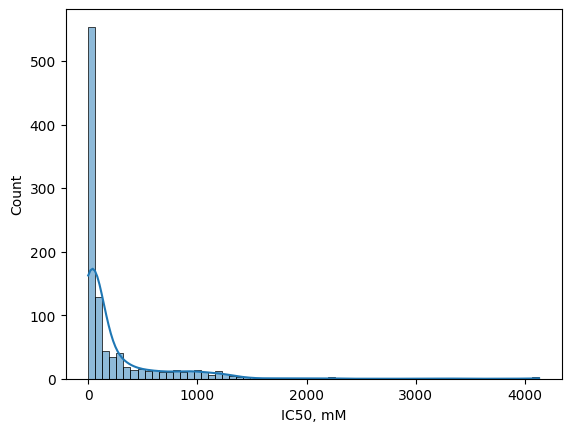

In [208]:
# загрузка данных
X = pd.read_excel('X_data.xlsx')
df_y = pd.read_excel('Y_data.xlsx')   
y = df_y['IC50, mM'] 

# визуализация распределения целевой переменной
sns.histplot(y, kde=True)

Распределение IC50 характеризуется выраженной положительной асимметрией и длинным правым хвостом. Большая часть значений сосредоточена в области низких концентраций, тогда как отдельные соединения имеют значительно более высокие значения IC50. Подобное распределение указывает на отклонение от нормальности и наличие выбросов, что может негативно влиять на качество линейных моделей машинного обучения. Для уменьшения асимметрии распределения и стабилизации дисперсии можно применить логарифмическую трансформацию целевой переменной. Сначала построим простую линейную регрессионную модель на исходных значениях цедевой переменной

In [209]:
# Линейная регрессия для предсказания IC50 на основе молекулярных дескрипторов до логарифмирования целевой переменной
# разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# стандартизация данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# обучение модели линейной регрессии        
model = LinearRegression()
model.fit(X_train, y_train)     

# предсказание на тестовой выборке
y_pred = model.predict(X_test)  

# оценка качества модели
mse = mean_squared_error(y_test, y_pred)    
r2 = r2_score(y_test, y_pred)

print('Линейная регрессия для предсказания IC50 на основе молекулярных дескрипторов до логарифмирования целевой переменной:')
print(f'Mean Squared Error: {mse:.2f}') 
print(f'R^2 Score: {r2:.2f}')           


Линейная регрессия для предсказания IC50 на основе молекулярных дескрипторов до логарифмирования целевой переменной:
Mean Squared Error: 169568.12
R^2 Score: 0.39


In [210]:
# Lasso-регрессия для предсказания IC50 на основе молекулярных дескрипторов до логарифмирования целевой переменной

# обучение модели Lasso-регрессии
lasso_model_raw = Lasso(alpha=0.1, max_iter=50000) 
lasso_model_raw.fit(X_train, y_train)

# предсказание на тестовой выборке
y_pred_lasso = lasso_model_raw.predict(X_test)

# оценка качества модели Lasso-регрессии
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print('Lasso-регрессия для предсказания IC50 на основе молекулярных дескрипторов до логарифмирования целевой переменной:')
print(f'Lasso Mean Squared Error: {mse_lasso:.2f}')
print(f'Lasso R^2 Score: {r2_lasso:.2f}')

Lasso-регрессия для предсказания IC50 на основе молекулярных дескрипторов до логарифмирования целевой переменной:
Lasso Mean Squared Error: 153459.39
Lasso R^2 Score: 0.44


In [211]:
# подбор оптимального значения параметра регуляризации alpha с помощью кросс-валидации
model = LassoCV(
    cv=5,
    random_state=42,
    max_iter=50000
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Оптимальное значение alpha и оценка качества модели:')
print(model.alpha_.round(4))
print(f'R^2 Score: {r2_score(y_test, y_pred):.2f}')

Оптимальное значение alpha и оценка качества модели:
2.4084
R^2 Score: 0.42


In [212]:
# Lasso регрессия с оптимальным alpha 2.4084

# обучение модели Lasso-регрессии с оптимальным alpha
lasso_model = Lasso(alpha=2.4084)      
lasso_model.fit(X_train, y_train)

# предсказание на тестовой выборке
y_pred_lasso = lasso_model.predict(X_test)

# оценка качества модели Lasso-регрессии
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print('Lasso-регрессия с оптимальным alpha 2.4084 для предсказания исходного IC50 на основе молекулярных дескрипторов:')
print(f'Lasso Mean Squared Error: {mse_lasso:.2f}')
print(f'Lasso R^2 Score: {r2_lasso:.2f}')

Lasso-регрессия с оптимальным alpha 2.4084 для предсказания исходного IC50 на основе молекулярных дескрипторов:
Lasso Mean Squared Error: 159657.08
Lasso R^2 Score: 0.42


In [196]:
# анализ коэффициентов Lasso-регрессии
print(np.sum(lasso_model.coef_ != 0))
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_model.coef_
})

coef_df = coef_df[coef_df['Coefficient'] != 0]

coef_df.sort_values(by='Coefficient', ascending=False)

75


,Feature,Coefficient
7,FpDensityMorgan1,129.729889
93,NumSaturatedRings,85.685832
47,SMR_VSA9,65.753901
111,fr_alkyl_halide,58.253963
127,fr_methoxy,48.510192
...,...,...
135,fr_priamide,-56.021153
9,FpDensityMorgan3,-80.646807
107,fr_NH2,-80.957344
24,Kappa3,-114.267370


<Axes: xlabel='log_IC50', ylabel='Count'>

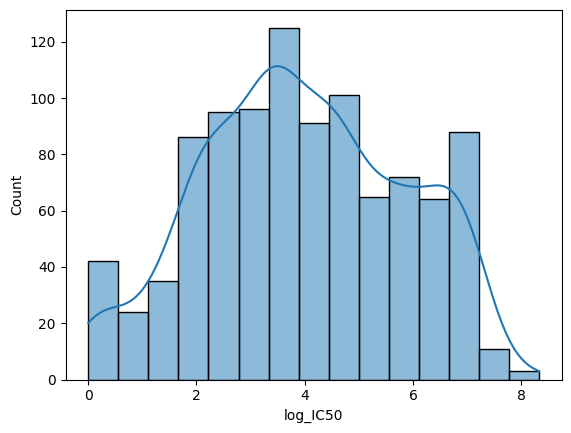

In [213]:
# логарифмирование целевой переменной IC50 для улучшения распределения и повышения точности модели
df_y['log_IC50'] = np.log1p(df_y['IC50, mM'])

# визуализация распределения целевой переменной после логарифмирования
sns.histplot(df_y['log_IC50'], kde=True)

Для уменьшения асимметрии распределения и стабилизации дисперсии была применена логарифмическая трансформация целевой переменной. После логарифмирования распределение IC50 стало более близким к нормальному, а влияние экстремально больших значений уменьшилось.

In [214]:
# Линейная регрессия для предсказания логарифмированного IC50 на основе молекулярных дескрипторов
y = df_y['log_IC50']

# разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# стандартизация данных
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# обучение модели линейной регрессии        
model = LinearRegression()
model.fit(X_train, y_train)     

# предсказание на тестовой выборке
y_pred = model.predict(X_test)  

# оценка качества модели
mse = mean_squared_error(y_test, y_pred)    
r2 = r2_score(y_test, y_pred)

print('Линейная регрессия для предсказания логарифмированного IC50 на основе молекулярных дескрипторов:')
print(f'Mean Squared Error: {mse:.2f}') 
print(f'R^2 Score: {r2:.2f}')    

Линейная регрессия для предсказания логарифмированного IC50 на основе молекулярных дескрипторов:
Mean Squared Error: 4.17
R^2 Score: -0.07


In [216]:
# Lasso регрессия для предсказания логарифмированного IC50 на основе молекулярных дескрипторов

# обучение модели Lasso-регрессии
lasso_model = Lasso(alpha=0.1, max_iter=50000)      
lasso_model.fit(X_train, y_train)

# предсказание на тестовой выборке
y_pred_lasso = lasso_model.predict(X_test)

# оценка качества модели Lasso-регрессии
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print('Lasso-регрессия для предсказания логарифмированного IC50 на основе молекулярных дескрипторов:')
print(f'Lasso Mean Squared Error: {mse_lasso:.2f}')
print(f'Lasso R^2 Score: {r2_lasso:.2f}')

Lasso-регрессия для предсказания логарифмированного IC50 на основе молекулярных дескрипторов:
Lasso Mean Squared Error: 2.83
Lasso R^2 Score: 0.27


In [217]:
# подбор оптимального значения параметра регуляризации alpha с помощью кросс-валидации
model = LassoCV(
    cv=5,
    random_state=42,
    max_iter=50000
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Оптимальное значение alpha и оценка качества модели:')
print(model.alpha_.round(4))
print(f'R^2 Score: {r2_score(y_test, y_pred):.2f}')

Оптимальное значение alpha и оценка качества модели:
0.0313
R^2 Score: 0.37


In [202]:
# Lasso регрессия с оптимальным alpha 0.0313

# обучение модели Lasso-регрессии с оптимальным alpha
lasso_model = Lasso(alpha=0.0313)      
lasso_model.fit(X_train, y_train)

# предсказание на тестовой выборке
y_pred_lasso = lasso_model.predict(X_test)

# оценка качества модели Lasso-регрессии
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print('Lasso-регрессия с оптимальным alpha 0.0313 для предсказания логарифмированного IC50 на основе молекулярных дескрипторов:')
print(f'Lasso Mean Squared Error: {mse_lasso:.2f}')
print(f'Lasso R^2 Score: {r2_lasso:.2f}')

Lasso-регрессия с оптимальным alpha 0.0313 для предсказания логарифмированного IC50 на основе молекулярных дескрипторов:
Lasso Mean Squared Error: 2.44
Lasso R^2 Score: 0.37


In [218]:
print(np.sum(lasso_model.coef_ != 0))
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_model.coef_
})

coef_df = coef_df[coef_df['Coefficient'] != 0]

coef_df.sort_values(by='Coefficient', ascending=False)

28


,Feature,Coefficient
92,NumSaturatedHeterocycles,0.369182
87,NumAromaticHeterocycles,0.130175
111,fr_alkyl_halide,0.068261
11,BCUT2D_MWLOW,0.068220
119,fr_furan,0.067415
109,fr_Ndealkylation2,0.047964
13,BCUT2D_CHGLO,0.041354
129,fr_nitro,0.034889
70,VSA_EState1,0.026941
103,fr_C_S,0.023443


#### Вывод: 

Для предсказания IC50 были исследованы линейная регрессия и Lasso-регрессия как на исходных, так и на логарифмированных значениях целевой переменной. Обычная линейная регрессия на исходных данных показала умеренное качество (R² ≈ 0.39), тогда как применение Lasso-регуляризации позволило улучшить результат до R² ≈ 0.44. Это свидетельствует о положительном влиянии регуляризации и отбора признаков при работе с высокоразмерными молекулярными дескрипторами и мультиколлинеарностью. 

Несмотря на выраженную положительную асимметрию распределения IC50, логарифмическая трансформация целевой переменной не привела к улучшению качества моделей. Для обычной линейной регрессии качество существенно ухудшилось (R² < 0), а для Lasso-регрессии результаты после логарифмирования также оказались ниже по сравнению с моделями на исходных значениях IC50, даже после подбора оптимального параметра регуляризации alpha.

Полученные результаты показывают, что логарифмическое преобразование уменьшило асимметрию распределения, однако не сделало зависимость между молекулярными дескрипторами и биологической активностью более линейной. 

При этом Lasso-регрессия оказалась наиболее эффективной среди линейных моделей благодаря способности снижать влияние мультиколлинеарности и автоматически отбирать наиболее информативные признаки.

In [204]:
# Decision Tree Regressor для предсказания исходного IC50 на основе молекулярных дескрипторов

y = df_y['IC50, mM'] 

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создание и обучение модели
max_depth = [3, 5, 7, 10]

for depth in max_depth:
    model = DecisionTreeRegressor(criterion='squared_error', max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    # Предсказание на тестовой выборке
    y_pred = model.predict(X_test)

    # Оценка качества модели
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f'Decision Tree Regressor (max_depth={depth}) для предсказания исходного IC50 на основе молекулярных дескрипторов:')
    print(f'Среднеквадратичная ошибка: {mse:.2f}')
    print(f'R²: {r2:.2f}')


Decision Tree Regressor (max_depth=3) для предсказания исходного IC50 на основе молекулярных дескрипторов:
Среднеквадратичная ошибка: 188301.85
R²: 0.32
Decision Tree Regressor (max_depth=5) для предсказания исходного IC50 на основе молекулярных дескрипторов:
Среднеквадратичная ошибка: 197123.93
R²: 0.29
Decision Tree Regressor (max_depth=7) для предсказания исходного IC50 на основе молекулярных дескрипторов:
Среднеквадратичная ошибка: 191073.42
R²: 0.31
Decision Tree Regressor (max_depth=10) для предсказания исходного IC50 на основе молекулярных дескрипторов:
Среднеквадратичная ошибка: 220205.51
R²: 0.20


После анализа линейных моделей было принято решение исследовать древовидные методы регрессии (DecisionTreeRegressor и RandomForestRegressor). Это связано с тем, что зависимость между молекулярными дескрипторами и биологической активностью соединений может иметь сложный нелинейный характер, который плохо описывается линейными моделями. Деревья решений способны автоматически учитывать нелинейные зависимости и взаимодействия между признаками без необходимости предварительного задания формы зависимости. Кроме того, древовидные модели менее чувствительны к мультиколлинеарности и не требуют нормальности распределения признаков и целевой переменной.

Одиночное дерево решений было использовано как базовая нелинейная модель для оценки возможности описания более сложных зависимостей между молекулярными дескрипторами и исходными значениями IC50 без логарифмического преобразования целевой переменной. Модель DecisionTreeRegressor показала умеренное качество (R² ≈ 0.32), уступая Lasso-регрессии. 

Полученные результаты свидетельствуют о том, что использование нелинейного подхода действительно позволяет учитывать более сложные зависимости между признаками и биологической активностью. Однако одиночное дерево решений оказалось недостаточно устойчивым и склонным к переобучению, что ограничило качество предсказания.
В связи с этим далее был исследован ансамблевый метод RandomForestRegressor, позволяющий уменьшить variance одиночных деревьев и повысить устойчивость модели за счёт усреднения большого количества деревьев решений.

In [205]:
# Random Forest Regressor для предсказания исходного IC50 на основе молекулярных дескрипторов

# обучение модели случайного леса с подбором гиперпараметров с помощью RandomizedSearchCV
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=50,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV R²:", search.best_score_)

# лучшая модель случайного леса
best_rf = search.best_estimator_

# предсказание на тестовой выборке
y_pred = best_rf.predict(X_test)

print('Random Forest Regressor для предсказания исходного IC50 на основе молекулярных дескрипторов:')
print(f'mse: {mean_squared_error(y_test, y_pred):.2f}')
print(f'R²: {r2_score(y_test, y_pred):.2f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': False}
Best CV R²: 0.39018749256939145
Random Forest Regressor для предсказания исходного IC50 на основе молекулярных дескрипторов:
mse: 153013.55
R²: 0.45


Для улучшения качества нелинейной модели был применён ансамблевый метод RandomForestRegressor. В отличие от одиночного дерева решений, случайный лес использует большое количество деревьев и усредняет их предсказания, что позволяет снизить переобучение и повысить устойчивость модели. 

Для подбора оптимальной архитектуры модели использовался RandomizedSearchCV с кросс-валидацией (cv=5). Подбирались параметры количества деревьев (n_estimators), глубины деревьев (max_depth), минимального числа объектов для разбиения (min_samples_split), минимального числа объектов в листьях (min_samples_leaf), способа выбора признаков (max_features) и использования bootstrap-выборок.

Оптимальная модель случайного леса показала качество R² ≈ 0.45, что оказалось выше результатов DecisionTreeRegressor и немного лучше Lasso-регрессии. Полученные результаты свидетельствуют о наличии нелинейных зависимостей между молекулярными дескрипторами и биологической активностью соединений.

Использование ансамблевого подхода позволило существенно повысить устойчивость модели по сравнению с одиночным деревом решений и уменьшить влияние переобучения. При этом преимущество RandomForestRegressor над Lasso-регрессией оказалось умеренным, что может указывать на сочетание линейных и нелинейных закономерностей в данных.

<Axes: title={'center': 'Важность признаков после обучения случайного леса'}, ylabel='Feature'>

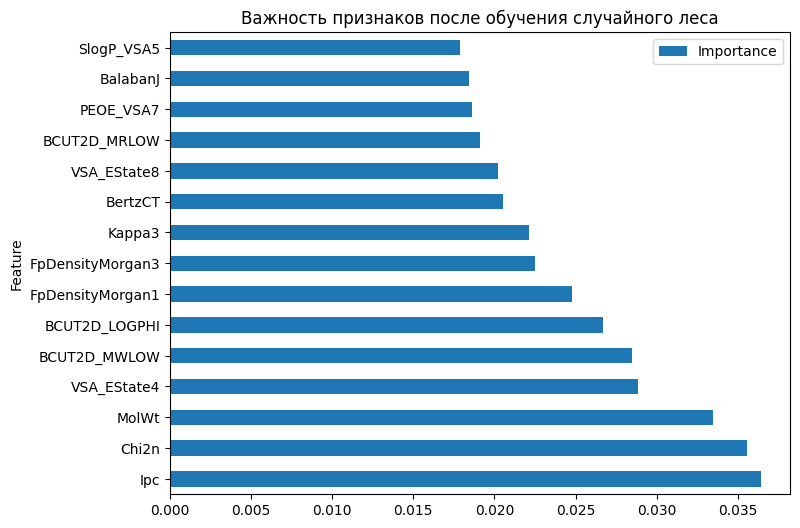

In [161]:
# визуализация важности признаков после обучения случайного леса
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df.head(15).plot.barh(
    x='Feature',
    y='Importance',
    figsize=(8,6),
    title='Важность признаков после обучения случайного леса'
)

Анализ важности признаков RandomForestRegressor для прогнозирования IC50 показал, что наибольший вклад в качество модели вносят дескрипторы, характеризующие топологическую сложность, размер и физико-химические свойства молекул.

Среди наиболее значимых признаков модель выделила Ipc, Chi2n, MolWt, VSA_EState4, BCUT2D_MWLOW, BCUT2D_LOGPHI, а также FpDensityMorgan1/3 и Kappa3. Это свидетельствует о том, что биологическая активность соединений зависит от совокупности топологических, электронных и структурных характеристик молекулы.

Высокая важность дескрипторов MolWt, Kappa3, Ipc и BertzCT указывает на существенное влияние размера и структурной сложности молекулы на значения IC50. В свою очередь, значимость BCUT- и VSA-дескрипторов подтверждает важную роль электронных свойств и распределения зарядов в формировании биологической активности соединений.

Полученные результаты хорошо согласуются с выводами корреляционного анализа и подтверждают, что для прогнозирования IC50 наиболее информативными являются признаки, отражающие одновременно топологические, физико-химические и электронные свойства молекул.

In [191]:
# CatBoost Regressor для предсказания исходного IC50 на основе молекулярных дескрипторов
# обучение модели CatBoost Regressor
model_cb = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_state=42,
    verbose=0
)

model_cb.fit(X_train, y_train)

# предсказание на тестовой выборке
y_pred = model_cb.predict(X_test)

print('CatBoost Regressor для предсказания исходного IC50 на основе молекулярных дескрипторов:')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'R²: {r2_score(y_test, y_pred):.2f}')

CatBoost Regressor для предсказания исходного IC50 на основе молекулярных дескрипторов:
MSE: 147664.00
R²: 0.47


Для дальнейшего улучшения качества регрессионной модели был использован CatBoostRegressor — ансамблевый метод градиентного бустинга над деревьями решений. В отличие от случайного леса, где деревья обучаются независимо друг от друга, в boosting-подходе каждое последующее дерево корректирует ошибки предыдущих моделей, что позволяет более эффективно моделировать сложные зависимости в данных. CatBoostRegressor показал наилучшее качество среди рассмотренных моделей (R² ≈ 0.47, MSE ≈ 147664). Улучшение результатов по сравнению с RandomForestRegressor и линейными моделями свидетельствует о наличии сложных нелинейных зависимостей между молекулярными дескрипторами и биологической активностью соединений.

Полученные результаты также показывают, что ансамблевые boosting-модели лучше справляются с высокоразмерными QSAR-данными, содержащими большое количество взаимосвязанных дескрипторов и сложные взаимодействия между признаками.
Несмотря на то, что CatBoostRegressor продемонстрировал лучшие результаты среди протестированных моделей, значение R² остаётся умеренным. Это указывает на высокую сложность задачи прогнозирования IC50 и вероятное влияние факторов, не полностью описываемых используемыми молекулярными дескрипторами.

<Axes: title={'center': 'Важность признаков после обучения catboost'}, ylabel='Feature'>

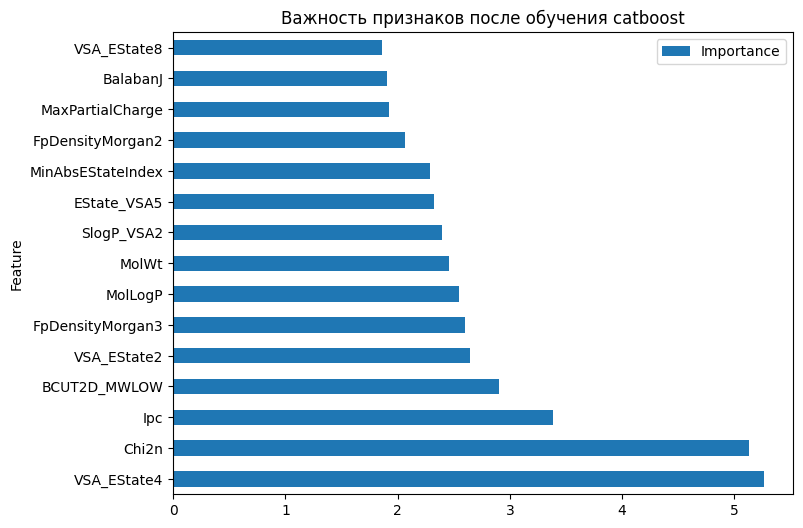

In [163]:
# визуализация важности признаков после обучения catboost
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_cb.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df.head(15).plot.barh(
    x='Feature',
    y='Importance',
    figsize=(8,6),
    title='Важность признаков после обучения catboost'
)

Анализ важности признаков CatBoostRegressor для прогнозирования IC50 показал, что наибольший вклад в качество модели вносят дескрипторы, отражающие топологические, электронные и физико-химические свойства молекул.

Среди наиболее значимых признаков модель выделила VSA_EState4, Chi2n, Ipc, BCUT2D_MWLOW, VSA_EState2, MolLogP и MolWt. Это свидетельствует о том, что биологическая активность соединений определяется сочетанием структурной сложности молекулы, распределения электронной плотности и липофильности.

Высокая важность дескрипторов MolLogP и MolWt указывает на влияние гидрофобности и размера молекулы на значения IC50. Значимость BCUT- и EState-дескрипторов подтверждает важную роль электронных характеристик и распределения зарядов в формировании биологической активности соединений.

Полученные результаты согласуются с выводами моделей Lasso и RandomForestRegressor, что подтверждает устойчивую значимость ряда топологических и электронных дескрипторов для прогнозирования IC50. Это также указывает на сложный многомерный характер зависимости между молекулярной структурой и биологической активностью соединений.

#### Вывод:

В ходе работы были исследованы различные подходы к прогнозированию биологической активности соединений (IC50) на основе молекулярных дескрипторов. 
Сравнение линейных моделей показало, что Lasso-регрессия превосходит обычную линейную регрессию благодаря способности уменьшать влияние мультиколлинеарности и автоматически отбирать наиболее информативные признаки. При этом логарифмическое преобразование целевой переменной не привело к улучшению качества моделей, несмотря на уменьшение асимметрии распределения IC50.

Использование нелинейных моделей позволило лучше описать сложные зависимости между молекулярными дескрипторами и биологической активностью соединений. Одиночное дерево решений показало ограниченное качество и склонность к переобучению, тогда как ансамблевые методы (RandomForestRegressor и CatBoostRegressor) продемонстрировали более устойчивые результаты.

Наилучшее качество среди исследованных моделей показал CatBoostRegressor (R² ≈ 0.47), продемонстрировав наилучшее качество среди исследованных моделей. Полученные результаты свидетельствуют о наличии как линейных, так и нелинейных закономерностей в данных, а также подтверждают эффективность ансамблевых boosting-моделей для решения QSAR-задач.
Несмотря на использование различных методов машинного обучения, качество моделей оказалось умеренным, что указывает на высокую сложность прогнозирования IC50 и вероятное влияние дополнительных факторов, не полностью описываемых используемыми молекулярными дескрипторами.